# Model Comparison & Explainable Prediction — Titanic Survival

**Goal:** compare two classifiers (Logistic Regression vs Random Forest) on the Titanic dataset, pick the better one using measured evidence, and provide a small prediction function.

**Workflow:** 1. Load & explore → 2. Preprocessing → 3. Training → 4. Evaluation & comparison → 5. Model selection → 6. Prediction → 7. Limitations

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

RANDOM_STATE = 42          # fixed seed -> reproducible split and models
np.random.seed(RANDOM_STATE)

## 1. Load & explore the dataset

In [2]:
df = sns.load_dataset('titanic')   # 891 passengers, 15 columns
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print('Missing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])
print('\nTarget balance (survived):')
print(df['survived'].value_counts(normalize=True).round(3))

Missing values per column:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Target balance (survived):
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


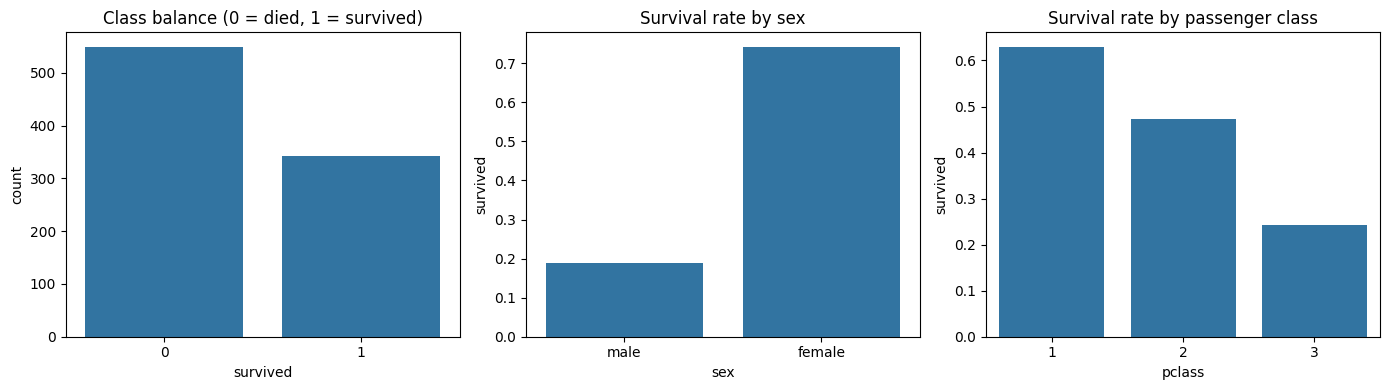

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(data=df, x='survived', ax=axes[0]); axes[0].set_title('Class balance (0 = died, 1 = survived)')
sns.barplot(data=df, x='sex', y='survived', ax=axes[1], errorbar=None); axes[1].set_title('Survival rate by sex')
sns.barplot(data=df, x='pclass', y='survived', ax=axes[2], errorbar=None); axes[2].set_title('Survival rate by passenger class')
plt.tight_layout(); plt.savefig('fig_eda.png', dpi=150); plt.show()

## 2. Preprocessing

- **Features kept:** `pclass, sex, age, sibsp, parch, fare, embarked`.
- **Dropped:** `deck` (77% missing), and columns that duplicate or leak the target (`alive`, `class`, `who`, `adult_male`, `embark_town`, `alone`).
- **Missing values:** `age` → median; `embarked` → most frequent. Imputers are fitted **on training data only** (inside the pipeline) to avoid leakage.
- **Encoding:** one-hot for `sex`, `embarked`; numeric columns scaled (needed for Logistic Regression, harmless for Random Forest).
- **Split:** 80/20, stratified on the target, `random_state=42`.

In [5]:
FEATURES = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
TARGET = 'survived'
NUM_COLS = ['pclass', 'age', 'sibsp', 'parch', 'fare']
CAT_COLS = ['sex', 'embarked']

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)

numeric_pipe = Pipeline([('impute', SimpleImputer(strategy='median')),
                         ('scale', StandardScaler())])
categorical_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                             ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_pipe, NUM_COLS),
                                  ('cat', categorical_pipe, CAT_COLS)])

Train: (712, 7)  Test: (179, 7)


## 3. Training (two models)

In [6]:
models = {
    'Logistic Regression': Pipeline([('prep', preprocessor),
                                     ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([('prep', preprocessor),
                               ('clf', RandomForestClassifier(n_estimators=200, max_depth=6,
                                                              random_state=RANDOM_STATE))]),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f'Trained: {name}')

Trained: Logistic Regression
Trained: Random Forest


## 4. Evaluation & comparison

In [7]:
rows, preds = [], {}
for name, m in models.items():
    p = m.predict(X_test); preds[name] = p
    rows.append({'Model': name,
                 'Accuracy':  accuracy_score(y_test, p),
                 'Precision': precision_score(y_test, p),
                 'Recall':    recall_score(y_test, p),
                 'F1-score':  f1_score(y_test, p)})
results = pd.DataFrame(rows).set_index('Model').round(3)
results.to_csv('metrics.csv')
results

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.804,0.793,0.667,0.724
Random Forest,0.816,0.875,0.609,0.718


In [8]:
# Stability check: 5-fold cross-validated F1 on the TRAINING set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, m in models.items():
    s = cross_val_score(m, X_train, y_train, cv=cv, scoring='f1')
    cv_rows.append({'Model': name, 'CV F1 mean': s.mean(), 'CV F1 std': s.std()})
cv_results = pd.DataFrame(cv_rows).set_index('Model').round(3)
cv_results.to_csv('cv.csv')
cv_results

,CV F1 mean,CV F1 std
Model,,
Logistic Regression,0.726,0.034
Random Forest,0.738,0.028


In [9]:
for name, p in preds.items():
    print(f'=== {name} ===')
    print(classification_report(y_test, p, target_names=['Died', 'Survived']))

=== Logistic Regression ===
              precision    recall  f1-score   support

        Died       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

=== Random Forest ===
              precision    recall  f1-score   support

        Died       0.79      0.95      0.86       110
    Survived       0.88      0.61      0.72        69

    accuracy                           0.82       179
   macro avg       0.83      0.78      0.79       179
weighted avg       0.83      0.82      0.81       179



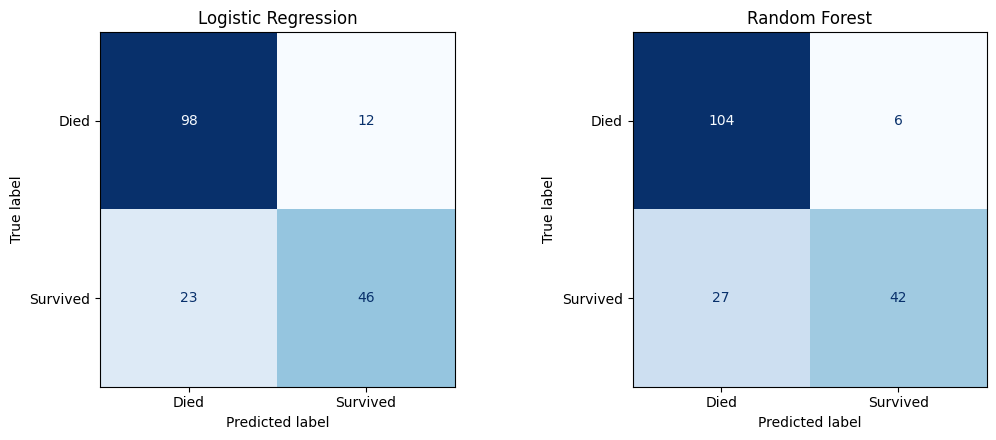

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, p) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p), display_labels=['Died', 'Survived']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig('fig_confusion.png', dpi=150); plt.show()

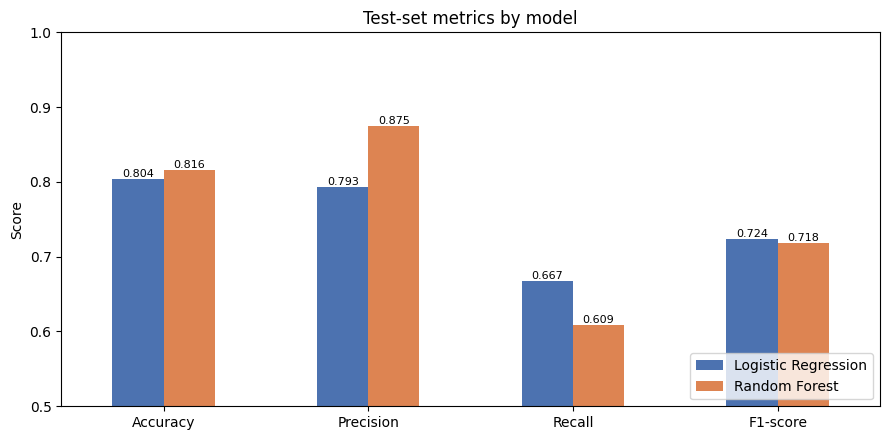

In [11]:
ax = results.T.plot(kind='bar', figsize=(9, 4.5), rot=0, color=['#4C72B0', '#DD8452'])
ax.set_ylim(0.5, 1.0); ax.set_ylabel('Score'); ax.set_title('Test-set metrics by model')
ax.legend(loc='lower right')
for c in ax.containers: ax.bar_label(c, fmt='%.3f', fontsize=8)
plt.tight_layout(); plt.savefig('fig_metrics.png', dpi=150); plt.show()

## 5. Explainability — what drives the chosen model?

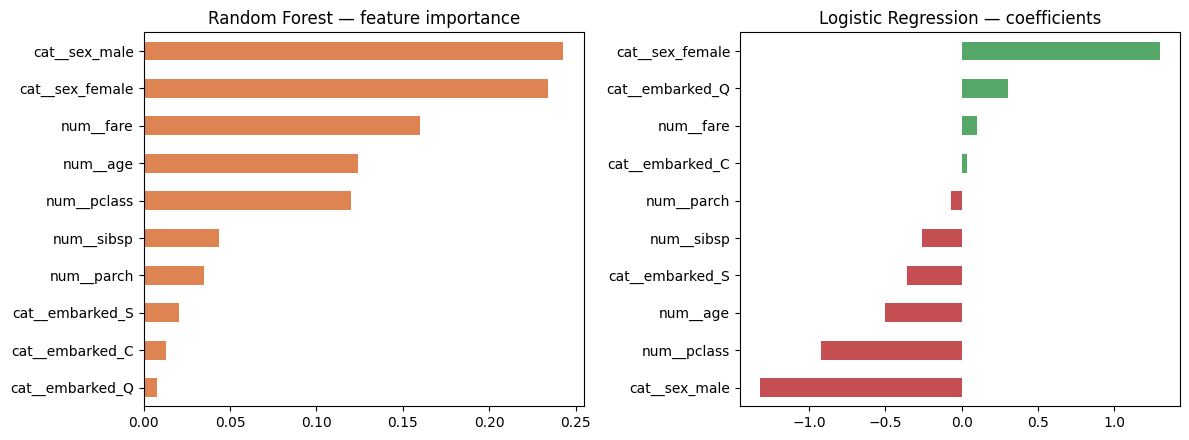

cat__sex_male      0.242
cat__sex_female    0.234
num__fare          0.160
num__age           0.124
num__pclass        0.120
num__sibsp         0.043
num__parch         0.035
cat__embarked_S    0.021
cat__embarked_C    0.013
cat__embarked_Q    0.008
dtype: float64


In [12]:
rf = models['Random Forest']
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names).sort_values()
lr = models['Logistic Regression']
coef = pd.Series(lr.named_steps['clf'].coef_[0], index=feat_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
imp.plot(kind='barh', ax=axes[0], color='#DD8452'); axes[0].set_title('Random Forest — feature importance')
coef.plot(kind='barh', ax=axes[1], color=['#C44E52' if v < 0 else '#55A868' for v in coef]); axes[1].set_title('Logistic Regression — coefficients')
plt.tight_layout(); plt.savefig('fig_importance.png', dpi=150); plt.show()
print(imp.sort_values(ascending=False).round(3))

## 6. Why I Selected This Model

**Selection rule (decided before looking at results):** primary metric = test **F1-score**, because the classes are imbalanced (≈62% died / 38% survived) and F1 balances precision and recall instead of rewarding the majority class. Cross-validated F1 is the stability check. If the two models are within noise, prefer the simpler, more explainable one.

**Outcome:** Logistic Regression has the higher test F1 (0.724 vs 0.718) and clearly higher recall (0.667 vs 0.609 — it finds 4 more of the 69 survivors). Random Forest wins accuracy and precision, and its CV F1 is slightly higher (0.738 vs 0.726), but that gap is smaller than one standard deviation (≈0.03), so the two are effectively tied on stability. With performance tied, Logistic Regression is selected because it is simpler, faster, and its coefficients explain each prediction directly.

In [13]:
best = results['F1-score'].idxmax()
print('Selected model:', best)
print(results.loc[best])
print('CV F1:', cv_results.loc[best].to_dict())
final_model = models[best]

Selected model: Logistic Regression
Accuracy     0.804
Precision    0.793
Recall       0.667
F1-score     0.724
Name: Logistic Regression, dtype: float64
CV F1: {'CV F1 mean': 0.726, 'CV F1 std': 0.034}


## 7. Prediction on sample input

In [14]:
def predict_passenger(pclass, sex, age, sibsp, parch, fare, embarked, model=final_model):
    """Return predicted class ('Survived'/'Died') and survival probability for one passenger."""
    row = pd.DataFrame([{'pclass': pclass, 'sex': sex, 'age': age, 'sibsp': sibsp,
                         'parch': parch, 'fare': fare, 'embarked': embarked}])
    label = int(model.predict(row)[0])
    prob = float(model.predict_proba(row)[0, 1])
    return ('Survived' if label == 1 else 'Died'), round(prob, 3)

samples = [
    dict(pclass=1, sex='female', age=29, sibsp=0, parch=0, fare=100.0, embarked='C'),
    dict(pclass=3, sex='male',   age=22, sibsp=0, parch=0, fare=7.25,  embarked='S'),
    dict(pclass=2, sex='male',   age=5,  sibsp=1, parch=1, fare=26.0,  embarked='S'),
    dict(pclass=3, sex='female', age=np.nan, sibsp=1, parch=0, fare=15.5, embarked='Q'),  # missing age handled
]
out = pd.DataFrame(samples)
out[['Prediction', 'P(survive)']] = [predict_passenger(**s) for s in samples]
out.to_csv('samples.csv', index=False)
out

,pclass,sex,age,sibsp,parch,fare,embarked,Prediction,P(survive)
0,1,female,29.0,0,0,100.00,C,Survived,0.955
1,3,male,22.0,0,0,7.25,S,Died,0.111
2,2,male,5.0,1,1,26.00,S,Died,0.353
3,3,female,NaN,1,0,15.50,Q,Survived,0.672


## 8. Limitations

- **Small dataset:** 891 rows, 179 in the test set — a few predictions changing can move metrics by 1–2 points.
- **Historical and specific:** reflects 1912 evacuation rules ("women and children first"); it does not generalise to other settings.
- **Imputation:** 20% of ages are filled with the median, which blurs the age effect.
- **Missing context:** no information on cabin location, lifeboat access or crew instructions.
- **A high score is not production-readiness.** No external validation, no monitoring, no fairness review (the model leans heavily on `sex`), and no calibration check were done.